# Run MLP/CNN on MNIST/CIFAR-10

Note: HPC.py has been set up to run on the BluePebble HPC system (see HPC.sh). Hyperparameters (e.g. num_filters) may need to be tweaked in order for it to compute timely on a local device.

In [101]:
!python HPC.py

^C


# Recorded Data

In [2]:
train_mlp_mnist = [
    10.90, 90.74, 93.94, 95.39, 96.83, 96.96, 97.59, 97.80,
    98.15, 98.26, 98.53, 98.94, 99.26, 99.37, 99.46, 99.70,
    99.79, 99.83, 99.87, 99.90, 99.92
]

test_mlp_mnist = [
    10.39, 89.75, 91.90, 93.31, 94.05, 94.32, 94.50, 94.65,
    94.76, 94.91, 94.89, 95.07, 95.39, 95.34, 95.46, 95.44,
    95.60, 95.55, 95.56, 95.71, 95.64
]

train_cnn_mnist = [
    10.28, 92.52, 94.82, 96.54, 97.10, 97.43, 98.01, 98.60,
    98.68, 98.71, 99.02, 99.10, 99.14, 99.15, 99.29, 99.46,
    99.40, 99.37, 99.46, 99.58, 99.65
]

test_cnn_mnist = [
    11.01, 92.61, 94.44, 95.96, 96.47, 96.85, 97.30, 97.53,
    97.63, 97.57, 97.76, 97.75, 97.70, 97.82, 97.79, 97.84,
    97.78, 97.64, 97.93, 97.85, 97.93
]

train_mlp_cifar10 = [
    11.12, 38.73, 42.90, 43.23, 47.48, 47.39, 50.47, 52.34,
    51.39, 53.33, 52.91, 55.58, 57.61, 57.54, 56.97, 58.72,
    57.33, 60.59, 58.76, 62.14, 63.13
]

test_mlp_cifar10 = [
    11.29, 38.08, 42.14, 40.48, 44.40, 43.54, 45.57, 46.49,
    44.64, 45.14, 43.89, 45.58, 46.38, 45.32, 44.56, 45.21,
    43.96, 45.84, 43.74, 45.23, 45.15
]

train_cnn_cifar10 = [
    8.50, 59.94, 66.07, 67.78, 71.18, 71.61, 72.88, 75.07,
    75.56, 76.09, 76.82, 76.12, 78.06, 78.25, 78.40, 78.98,
    79.82, 79.94, 79.93, 80.78, 81.03
]

test_cnn_cifar10 = [
    8.33, 58.65, 64.11, 65.24, 67.78, 67.64, 68.79, 70.12,
    69.74, 70.57, 70.51, 69.44, 70.95, 70.83, 70.53, 70.95,
    70.81, 71.14, 70.93, 71.31, 71.22
]

# Plotting

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
epochs = list(range(21))
data = []
def add_series(dataset, model, split, values):
    for e, acc in enumerate(values):
        data.append({
            "Dataset": dataset,
            "Model": model,
            "Split": split,
            "Epoch": e,
            "Accuracy (%)": acc
        })

add_series("MNIST", "MLP", "Train", train_mlp_mnist)
add_series("MNIST", "MLP", "Test",  test_mlp_mnist)
add_series("MNIST", "CNN", "Train", train_cnn_mnist)
add_series("MNIST", "CNN", "Test",  test_cnn_mnist)

add_series("CIFAR-10", "MLP", "Train", train_mlp_cifar10)
add_series("CIFAR-10", "MLP", "Test",  test_mlp_cifar10)
add_series("CIFAR-10", "CNN", "Train", train_cnn_cifar10)
add_series("CIFAR-10", "CNN", "Test",  test_cnn_cifar10)

df = pd.DataFrame(data)



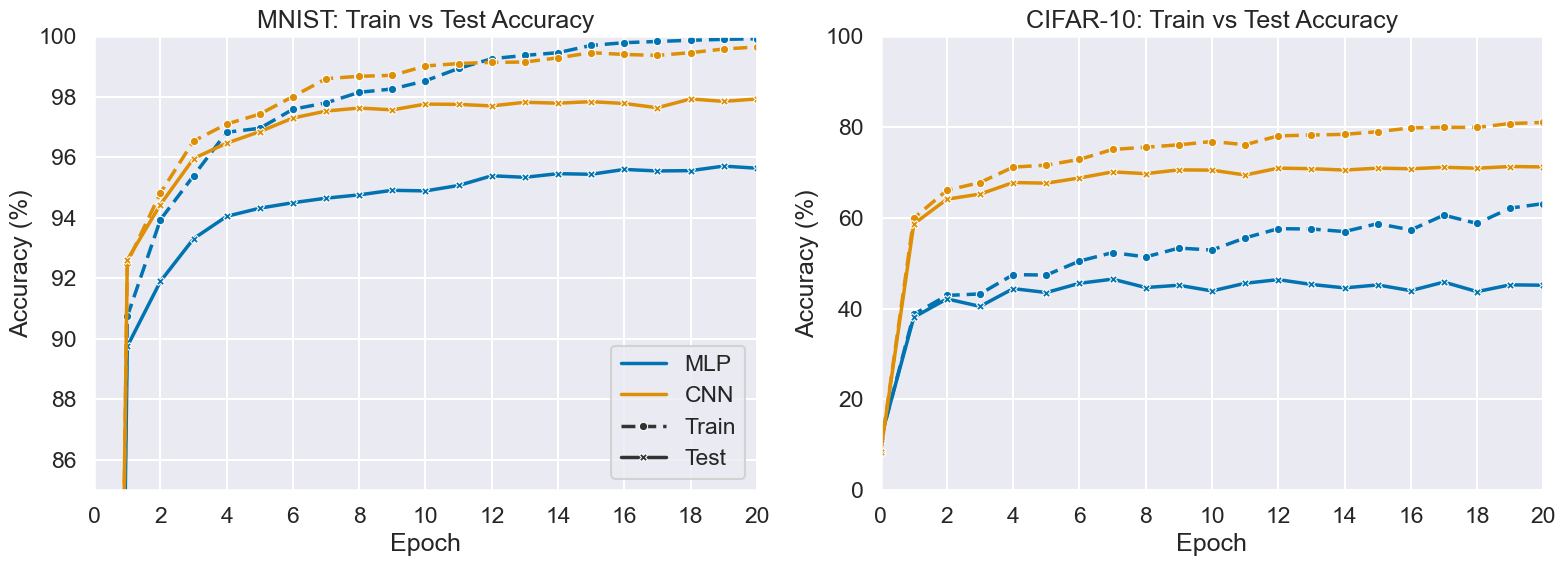

In [6]:
# PLOT:
sns.set_theme(style="darkgrid", context="talk", palette="colorblind")

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
axes[0].set_ylim(85, 100)   # MNIST zoomed
axes[1].set_ylim(0, 100)    # CIFAR full scale


for ax, dataset in zip(axes, ["MNIST", "CIFAR-10"]):
    subset = df[df["Dataset"] == dataset]

    sns.lineplot(
        data=subset,
        x="Epoch",
        y="Accuracy (%)",
        hue="Model",
        style="Split",
        markers=True,
        dashes={"Train": (4,2), "Test": ""},
        linewidth=2.5,
        markersize=6,
        ax=ax
    )

    ax.set_title(f"{dataset}: Train vs Test Accuracy")
    ax.set_xlim(0, 20)
    ax.set_xticks(range(0, 21, 2))
    ax.set_xlabel("Epoch")

    # --- Clean legend (remove "Model" and "Split") ---
    handles, labels = ax.get_legend_handles_labels()
    clean = [(h, l) for h, l in zip(handles, labels)
             if l not in ["Model", "Split"]]

    handles, labels = zip(*clean)
    ax.legend(handles, labels, loc="lower right", frameon=True)

axes[1].legend().remove()

plt.tight_layout()
plt.savefig("accuracies.png", dpi=300, bbox_inches="tight")
plt.show()